In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from scipy import stats
from sklearn.datasets import load_breast_cancer
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


In [10]:
c_list = ["#A63130", "#D54A38", "#EDB74D", "#A0B87B", "#46966E", "#306884"]
new_cmap = LinearSegmentedColormap.from_list('sci_standard', c_list)

In [11]:
def plot_heatmap(data, lane_index, tag, mpr):

    va_col = f"speed_{lane_index}"
    pos_col = f"pos_{lane_index}"
    time_col = f"time_stamp_{lane_index}"

    data = data[[va_col, pos_col, time_col]]
    data = data.dropna()
    data = data[data[time_col] >= 0]
    data[time_col] = data[time_col].astype(int)

    # Set the number of bins for the grid
    num_bins_time = 200
    num_bins_pos = 400
    
    # Calculate the average speed for each bin
    h, xedges, yedges, binnumbers = scipy.stats.binned_statistic_2d(
        data[time_col], 
        data[pos_col], 
        data[va_col], 
        statistic='mean', 
        bins=[num_bins_time, num_bins_pos]
    )

    # Calculate the overall mean speed of the dataset
    overall_mean_speed = np.mean(data[va_col])
    print("overall_mean_speed:", overall_mean_speed)

    # Fill the empty bins with the overall mean speed
    h[np.isnan(h)] = overall_mean_speed

    cmap = new_cmap
    cmap = cmap.with_extremes(bad=cmap(0))
    plt.figure(figsize=(14, 4))
    plt.ylim(300, 3250)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    # Plot the heatmap using the calculated average speeds
    pcm = plt.pcolormesh(xedges, yedges, h.T, cmap=cmap,
                         rasterized=True, vmin=0, vmax=33)
    
    cbar = plt.colorbar(pcm, label="Speed (m/s)", pad=0)
    cbar.set_label('Speed (m/s)', fontsize=25)
    # Set the font size of colorbar ticks
    cbar.ax.tick_params(labelsize=20)

    plt.xlabel('Time (s)', fontsize=25)  # Set the x-axis label
    plt.ylabel('Position (m)', fontsize=25)  # Set the y-axis label
    plt.title(f"MPR={mpr}%", fontsize=25)  # Set the title with MPR value
    plt.show()

### MPR 60

overall_mean_speed: 24.77175316937634


/tmp/ipykernel_68553/1135616714.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_60_flow_54_12_time_3600_ramp.csv')


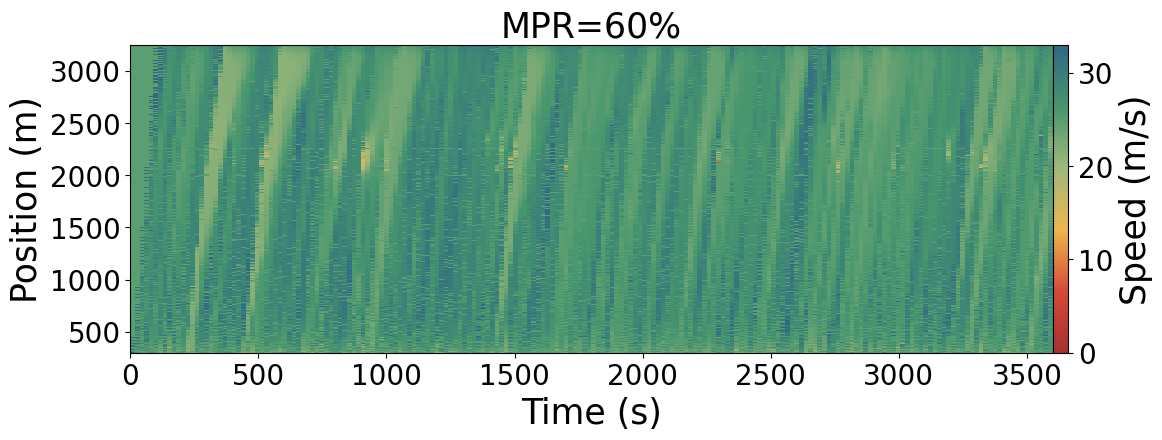

In [12]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_60_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_5", 60)

overall_mean_speed: 23.03913442099842


/tmp/ipykernel_68553/1011643428.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_60_flow_54_12_time_3600_ramp.csv')


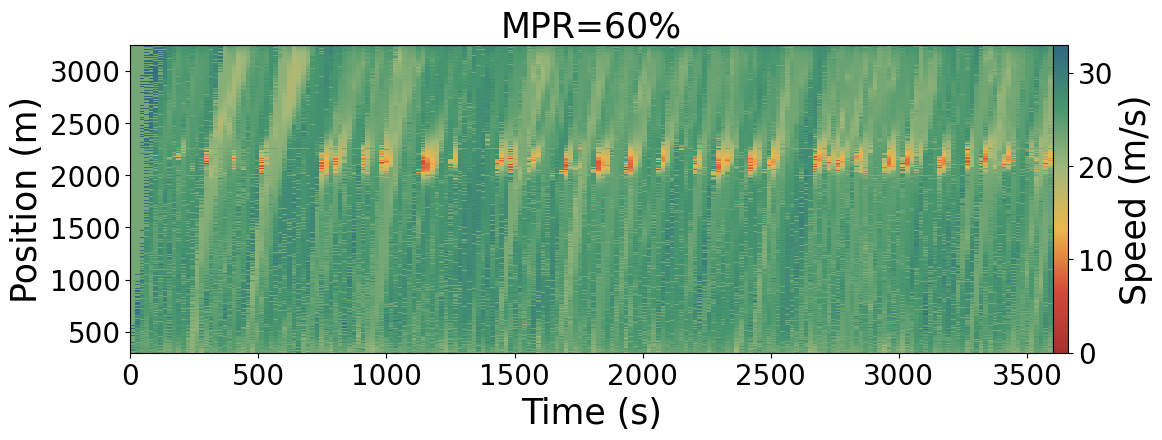

In [13]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_60_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'middle', "mpr_60_platoon_54_5", 60)

overall_mean_speed: 18.605513252680048


/tmp/ipykernel_68553/369943615.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_60_flow_54_12_time_3600_ramp.csv')


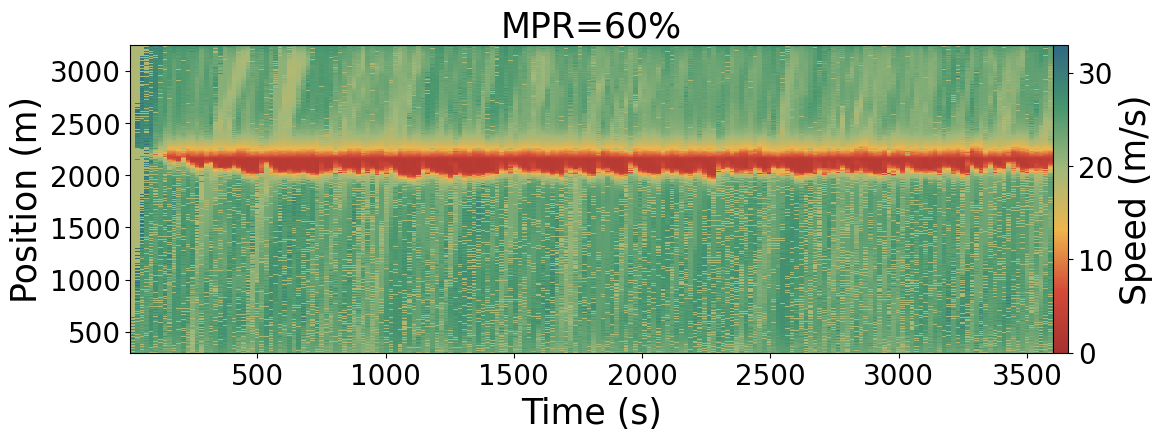

In [14]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_60_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'right', "mpr_60_platoon_54_5", 60)

---

### MPR 40

overall_mean_speed: 24.60843156182502


/tmp/ipykernel_68553/1421414498.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_40_flow_54_12_time_3600_ramp.csv')


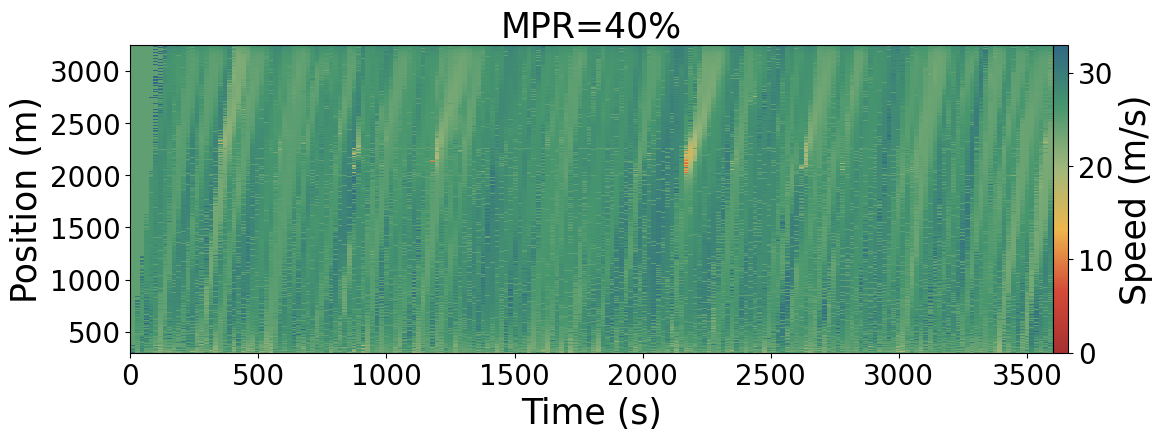

In [15]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_40_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_12", 40)

overall_mean_speed: 22.498941723884037


/tmp/ipykernel_68553/1501489690.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_40_flow_54_12_time_3600_ramp.csv')


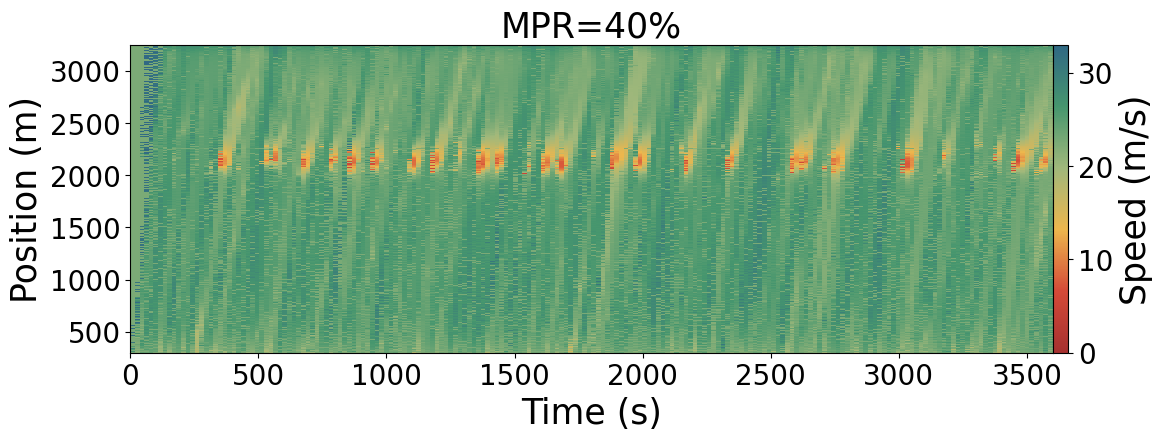

In [16]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_40_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'middle', "mpr_60_platoon_54_12", 40)

overall_mean_speed: 17.79293487634521


/tmp/ipykernel_68553/605478675.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_40_flow_54_12_time_3600_ramp.csv')


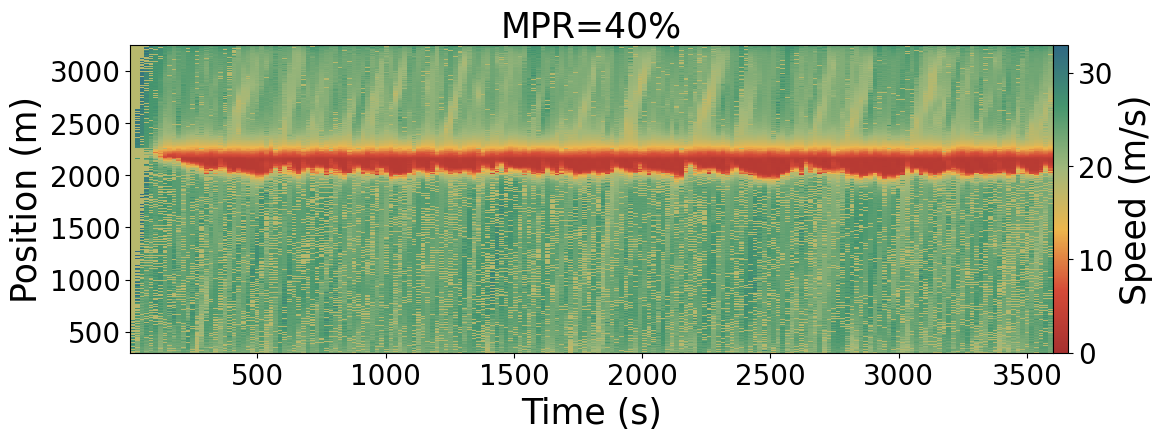

In [18]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_40_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'right', "mpr_60_platoon_54_12", 40)

---

### MPR 80

overall_mean_speed: 25.543249045865007


/tmp/ipykernel_68553/4164053414.py:1: DtypeWarning: Columns (21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_80_flow_54_12_time_3600_ramp.csv')


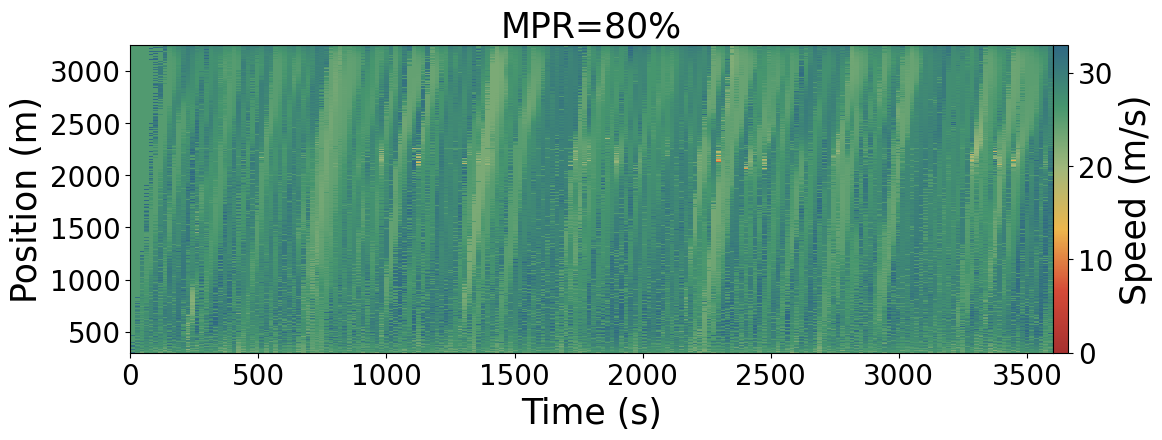

In [19]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_80_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_5", 80)

overall_mean_speed: 23.87018551390463


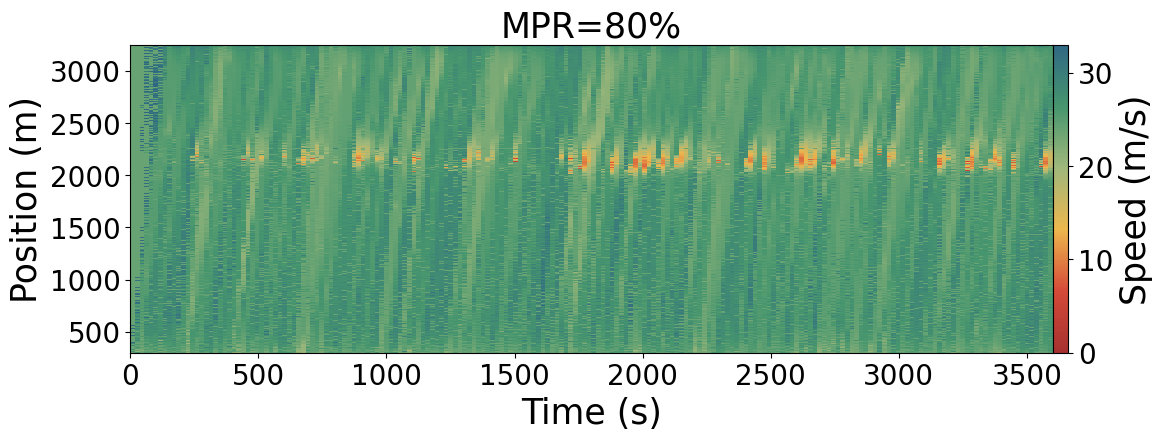

In [20]:
plot_heatmap(data, 'middle', "mpr_60_platoon_54_5", 80)

overall_mean_speed: 20.395532245690475


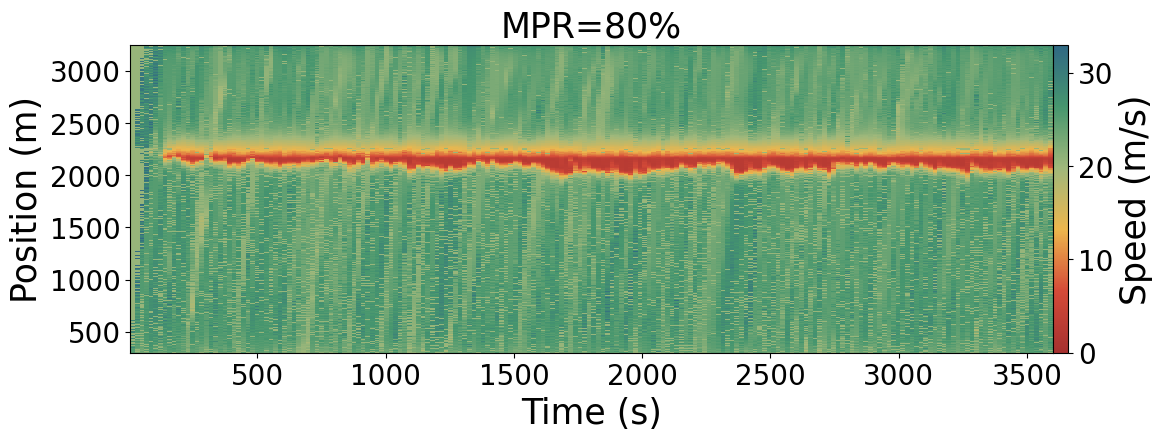

In [21]:
plot_heatmap(data, 'right', "mpr_60_platoon_54_5", 80)

### MPR 99

overall_mean_speed: 25.55490000341012


/tmp/ipykernel_68553/2507022937.py:1: DtypeWarning: Columns (21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('//home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_99_flow_54_12_time_3600_ramp.csv')


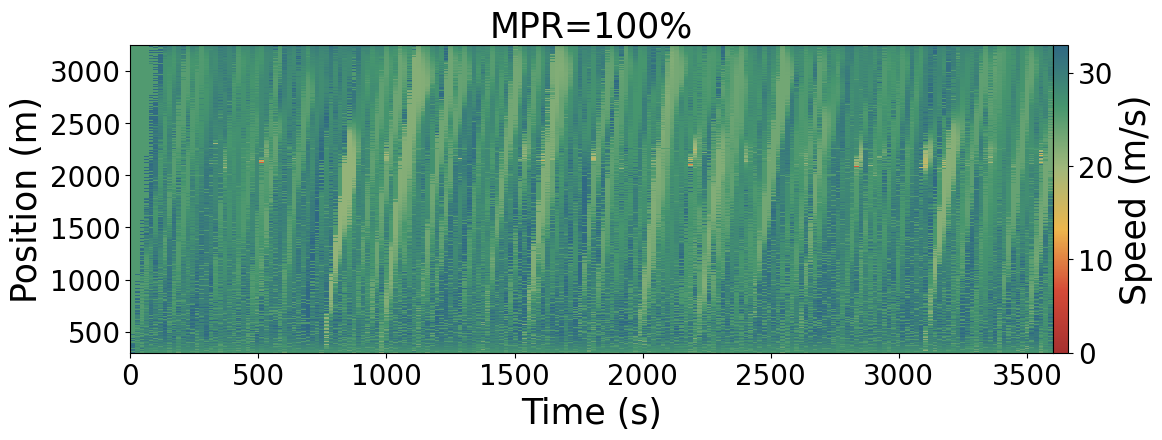

In [22]:
data = pd.read_csv('//home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/baseline_3600_mpr_99_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_5", 100)

overall_mean_speed: 24.411914061717592


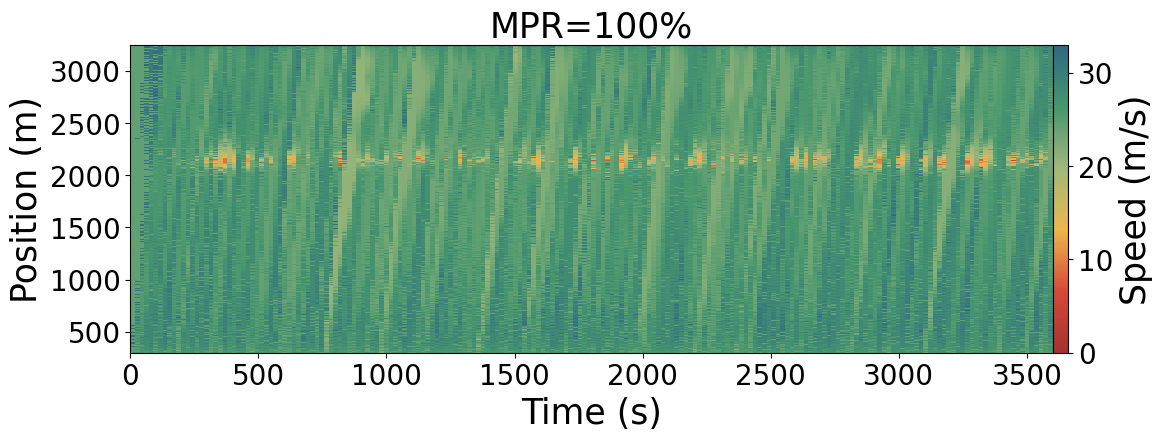

In [23]:
plot_heatmap(data, 'middle', "mpr_60_platoon_54_5", 100)

overall_mean_speed: 21.67863707695301


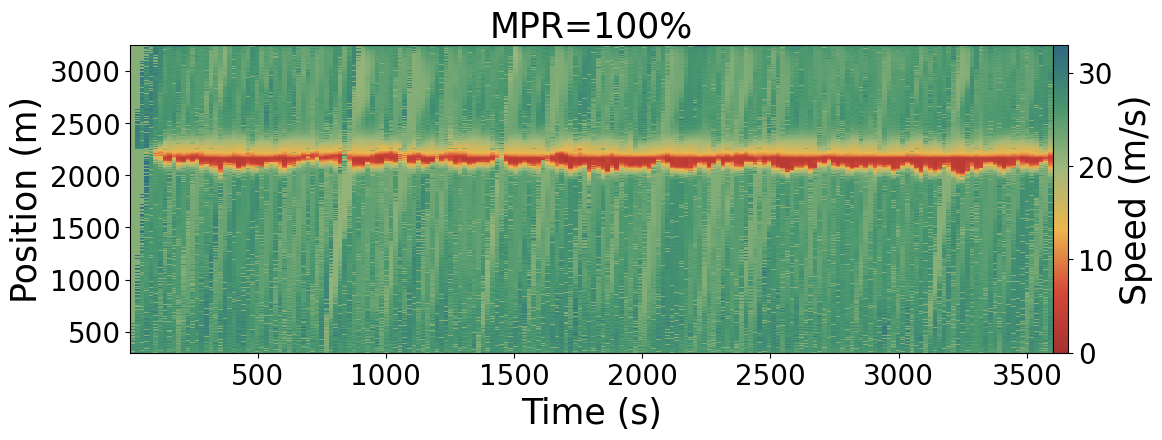

In [24]:
plot_heatmap(data, 'right', "mpr_60_platoon_54_5", 100)

# Hybrid Control

### MPR 40

overall_mean_speed: 25.29959908045909


/tmp/ipykernel_68553/2168978793.py:1: DtypeWarning: Columns (21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/hybrid_3600_mpr_40_flow_54_12_time_3600_ramp.csv')


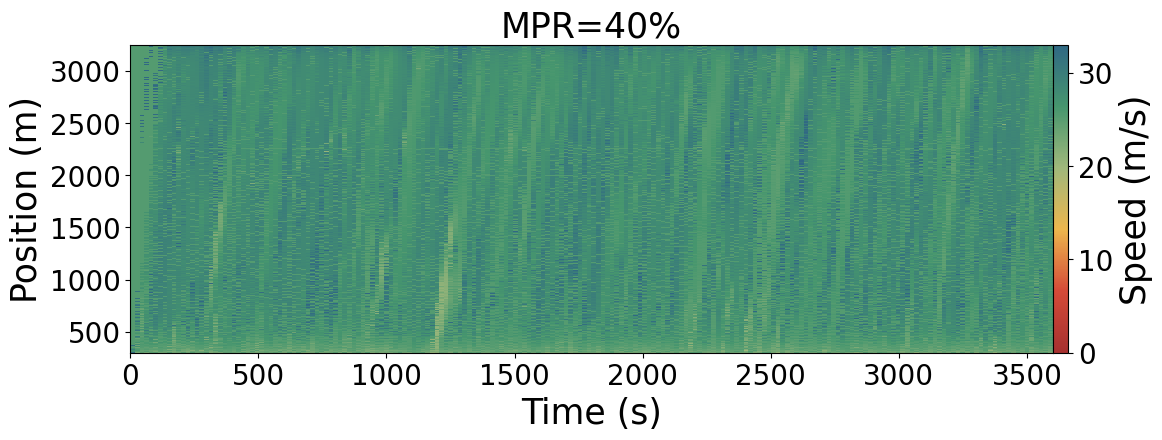

In [28]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/hybrid_3600_mpr_40_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_5", 40)

overall_mean_speed: 24.016726247965067


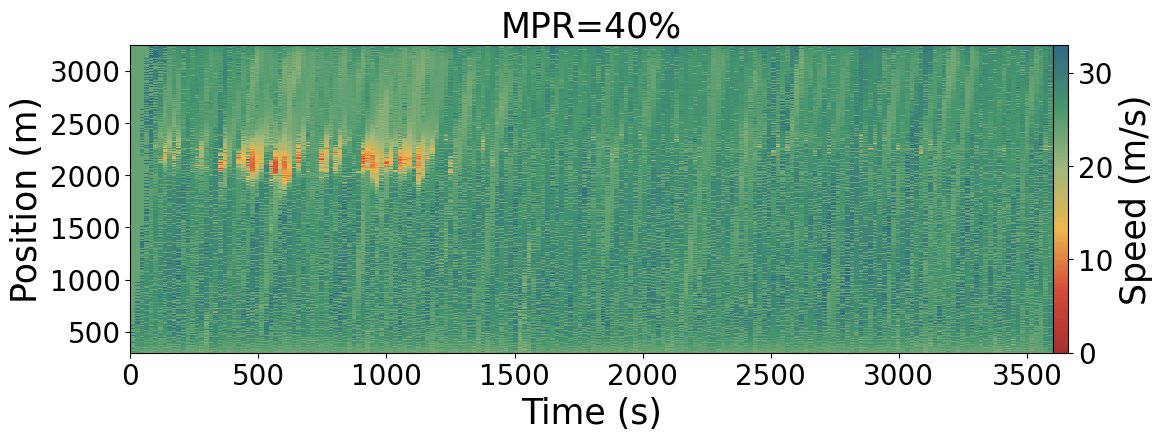

In [29]:
plot_heatmap(data, 'middle', "mpr_60_platoon_54_5", 40)

overall_mean_speed: 21.12900374385709


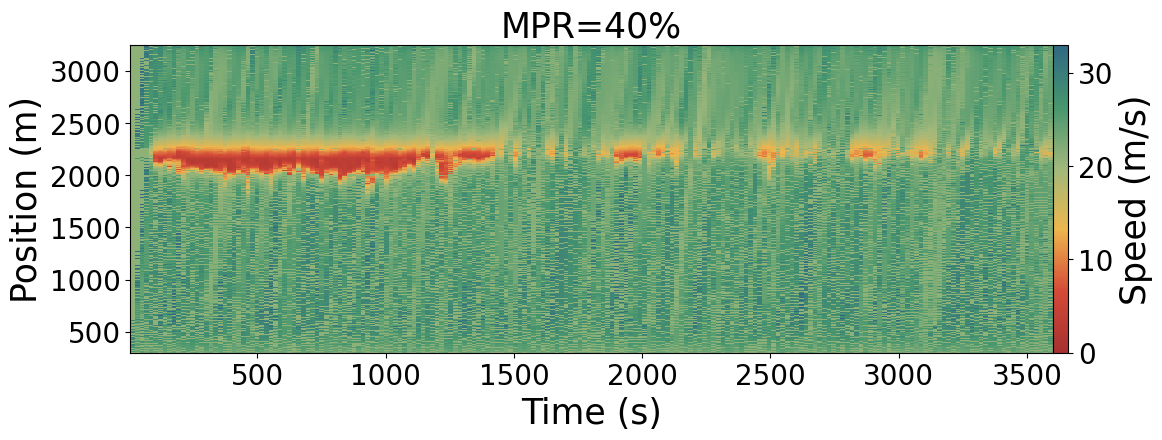

In [30]:
plot_heatmap(data, 'right', "mpr_60_platoon_54_5", 40)

### MPR 80

overall_mean_speed: 24.68716400626078


/tmp/ipykernel_68553/2094781113.py:1: DtypeWarning: Columns (7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/hybrid_3600_mpr_80_flow_54_12_time_3600_ramp.csv')


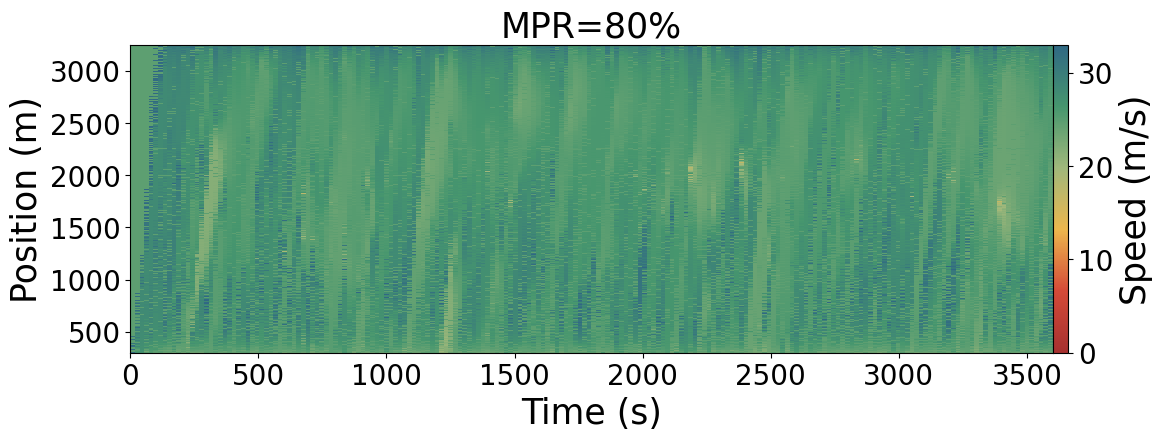

In [31]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/hybrid_3600_mpr_80_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_5", 80)

overall_mean_speed: 23.166589830930793


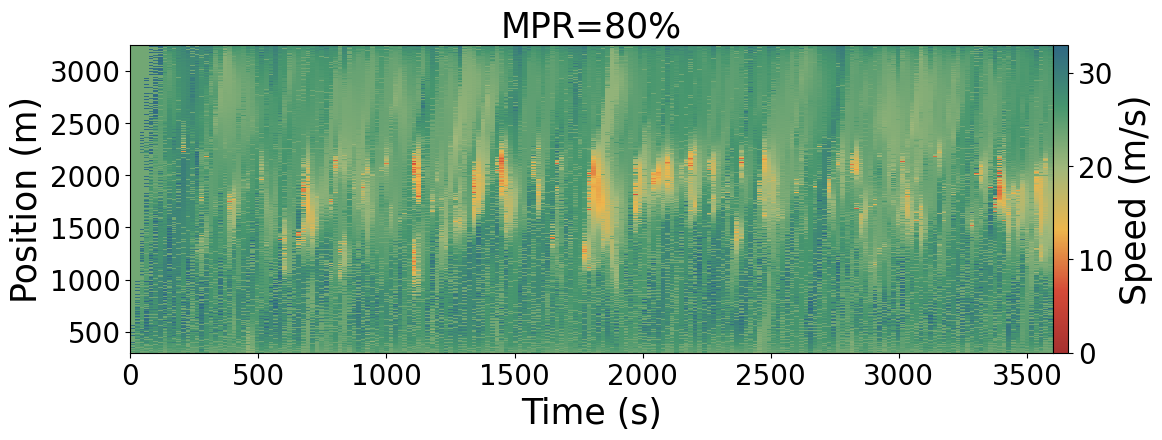

In [32]:
plot_heatmap(data, 'middle', "mpr_60_platoon_54_5", 80)

overall_mean_speed: 18.921499154454835


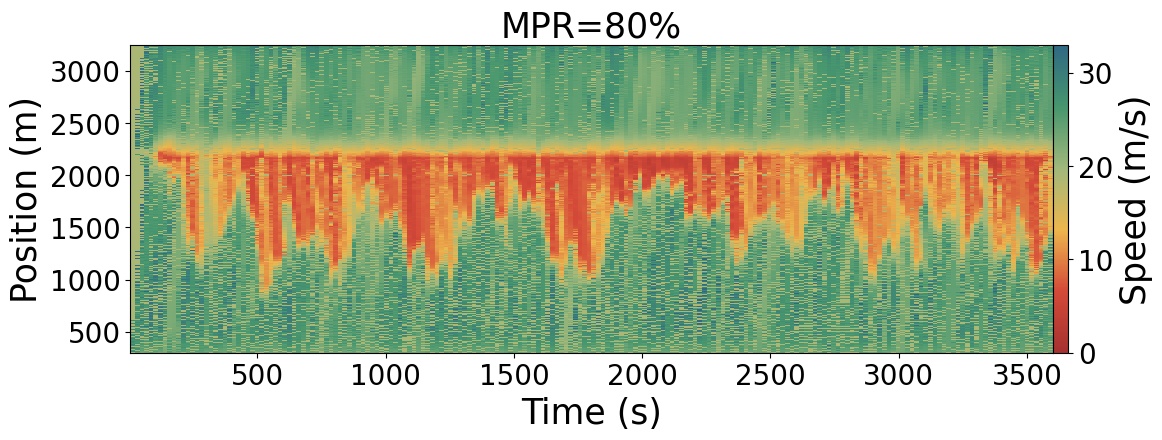

In [33]:
plot_heatmap(data, 'right', "mpr_60_platoon_54_5", 80)

### MPR 100

/tmp/ipykernel_68553/1806630091.py:1: DtypeWarning: Columns (0,1,2,7,8,9,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/hybrid_3600_mpr_99_flow_54_12_time_3600_ramp.csv')


overall_mean_speed: 23.425484710953402


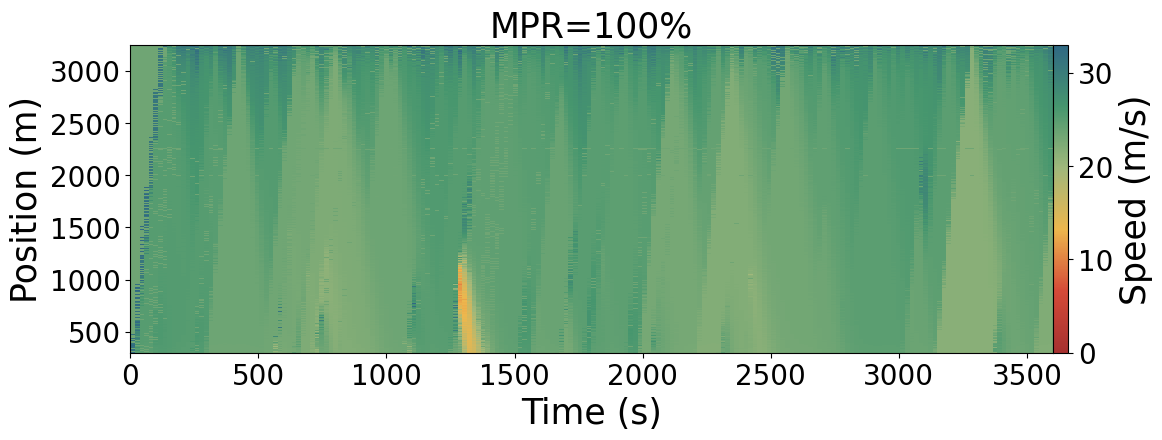

In [34]:
data = pd.read_csv('/home/ruby/Nazmus Shakib/AARC Lab/Draft Project/output/data/base_info_data/hybrid_3600_mpr_99_flow_54_12_time_3600_ramp.csv')
plot_heatmap(data, 'left', "mpr_60_platoon_54_5", 100)

overall_mean_speed: 20.343467482045792


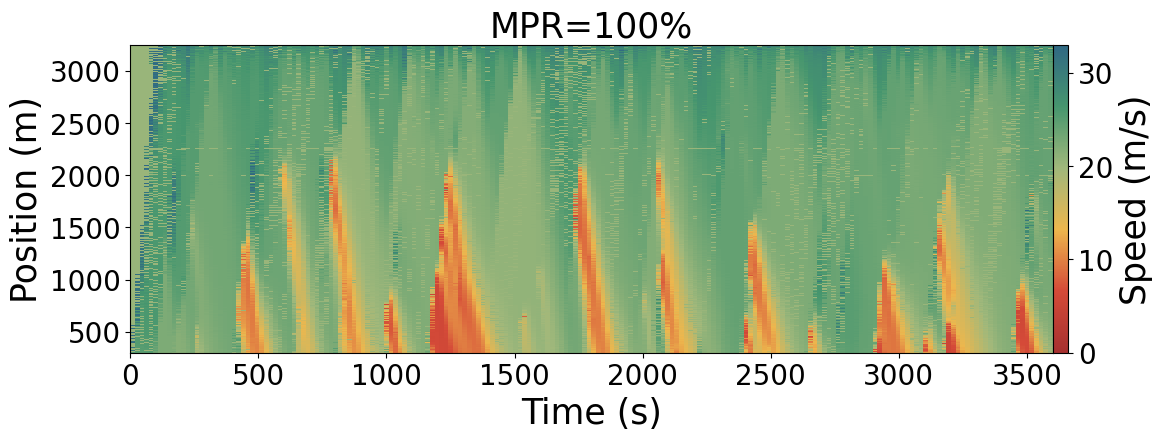

In [35]:
plot_heatmap(data, 'middle', "mpr_60_platoon_54_5", 100)

overall_mean_speed: 9.465302702119951


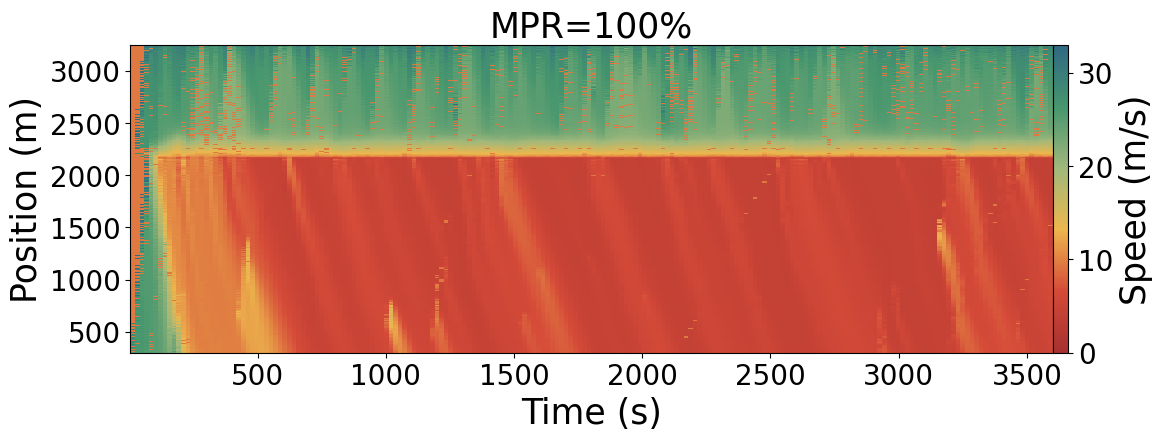

In [36]:
plot_heatmap(data, 'right', "mpr_60_platoon_54_5", 100)